EXploratory Data Analysis


In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('../data/raw/loan_data.csv')
df.head()

,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,...,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,application_type,mort_acc,pub_rec_bankruptcies,address
0,10000.0,36 months,11.44,329.48,B,B4,Marketing,10+ years,RENT,117000.0,...,16.0,0.0,36369.0,41.8,25.0,w,INDIVIDUAL,0.0,0.0,"0174 Michelle Gateway\nMendozaberg, OK 22690"
1,8000.0,36 months,11.99,265.68,B,B5,Credit analyst,4 years,MORTGAGE,65000.0,...,17.0,0.0,20131.0,53.3,27.0,f,INDIVIDUAL,3.0,0.0,"1076 Carney Fort Apt. 347\nLoganmouth, SD 05113"
2,15600.0,36 months,10.49,506.97,B,B3,Statistician,< 1 year,RENT,43057.0,...,13.0,0.0,11987.0,92.2,26.0,f,INDIVIDUAL,0.0,0.0,"87025 Mark Dale Apt. 269\nNew Sabrina, WV 05113"
3,7200.0,36 months,6.49,220.65,A,A2,Client Advocate,6 years,RENT,54000.0,...,6.0,0.0,5472.0,21.5,13.0,f,INDIVIDUAL,0.0,0.0,"823 Reid Ford\nDelacruzside, MA 00813"
4,24375.0,60 months,17.27,609.33,C,C5,Destiny Management Inc.,9 years,MORTGAGE,55000.0,...,13.0,0.0,24584.0,69.8,43.0,f,INDIVIDUAL,1.0,0.0,"679 Luna Roads\nGreggshire, VA 11650"


In [2]:
df.shape

(396030, 27)

In [3]:
df.columns.to_list()

['loan_amnt',
 'term',
 'int_rate',
 'installment',
 'grade',
 'sub_grade',
 'emp_title',
 'emp_length',
 'home_ownership',
 'annual_inc',
 'verification_status',
 'issue_d',
 'loan_status',
 'purpose',
 'title',
 'dti',
 'earliest_cr_line',
 'open_acc',
 'pub_rec',
 'revol_bal',
 'revol_util',
 'total_acc',
 'initial_list_status',
 'application_type',
 'mort_acc',
 'pub_rec_bankruptcies',
 'address']

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 396030 entries, 0 to 396029
Data columns (total 27 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   loan_amnt             396030 non-null  float64
 1   term                  396030 non-null  str    
 2   int_rate              396030 non-null  float64
 3   installment           396030 non-null  float64
 4   grade                 396030 non-null  str    
 5   sub_grade             396030 non-null  str    
 6   emp_title             373103 non-null  str    
 7   emp_length            377729 non-null  str    
 8   home_ownership        396030 non-null  str    
 9   annual_inc            396030 non-null  float64
 10  verification_status   396030 non-null  str    
 11  issue_d               396030 non-null  str    
 12  loan_status           396030 non-null  str    
 13  purpose               396030 non-null  str    
 14  title                 394274 non-null  str    
 15  dti        

In [5]:
missing = df.isnull().sum().sort_values(ascending=False)
missing.head(30)

mort_acc                37795
emp_title               22927
emp_length              18301
title                    1756
pub_rec_bankruptcies      535
revol_util                276
installment                 0
int_rate                    0
term                        0
grade                       0
loan_amnt                   0
verification_status         0
annual_inc                  0
home_ownership              0
sub_grade                   0
dti                         0
issue_d                     0
loan_status                 0
purpose                     0
pub_rec                     0
open_acc                    0
earliest_cr_line            0
revol_bal                   0
initial_list_status         0
total_acc                   0
application_type            0
address                     0
dtype: int64

In [6]:
df['loan_status'].value_counts()    

loan_status
Fully Paid     318357
Charged Off     77673
Name: count, dtype: int64

In [7]:
df['loan_status'] = df['loan_status'].map({'Fully Paid': 0, 'Charged Off': 1})
df['loan_status'].value_counts()

loan_status
0    318357
1     77673
Name: count, dtype: int64

In [8]:
df.describe()

,loan_amnt,int_rate,installment,annual_inc,loan_status,dti,open_acc,pub_rec,revol_bal,revol_util,total_acc,mort_acc,pub_rec_bankruptcies
count,396030.000000,396030.000000,396030.000000,3.960300e+05,396030.000000,396030.000000,396030.000000,396030.000000,3.960300e+05,395754.000000,396030.000000,358235.000000,395495.000000
mean,14113.888089,13.639400,431.849698,7.420318e+04,0.196129,17.379514,11.311153,0.178191,1.584454e+04,53.791749,25.414744,1.813991,0.121648
std,8357.441341,4.472157,250.727790,6.163762e+04,0.397068,18.019092,5.137649,0.530671,2.059184e+04,24.452193,11.886991,2.147930,0.356174
min,500.000000,5.320000,16.080000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,2.000000,0.000000,0.000000
25%,8000.000000,10.490000,250.330000,4.500000e+04,0.000000,11.280000,8.000000,0.000000,6.025000e+03,35.800000,17.000000,0.000000,0.000000
50%,12000.000000,13.330000,375.430000,6.400000e+04,0.000000,16.910000,10.000000,0.000000,1.118100e+04,54.800000,24.000000,1.000000,0.000000
75%,20000.000000,16.490000,567.300000,9.000000e+04,0.000000,22.980000,14.000000,0.000000,1.962000e+04,72.900000,32.000000,3.000000,0.000000
max,40000.000000,30.990000,1533.810000,8.706582e+06,1.000000,9999.000000,90.000000,86.000000,1.743266e+06,892.300000,151.000000,34.000000,8.000000


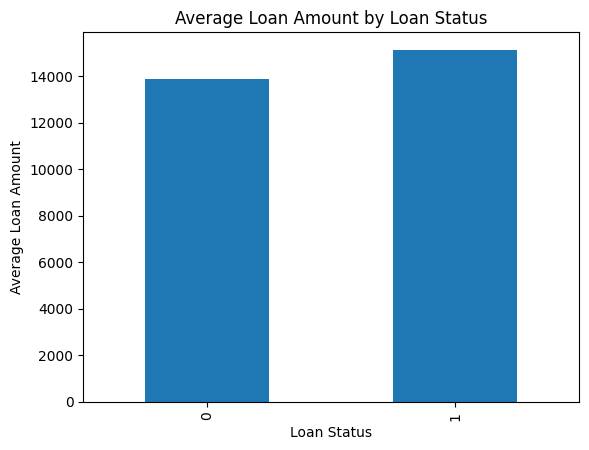

In [9]:
df.groupby('loan_status')['loan_amnt'].mean().plot(kind='bar')
plt.title('Average Loan Amount by Loan Status')
plt.xlabel('Loan Status')
plt.ylabel('Average Loan Amount')
plt.show()  

In [10]:
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

len(numerical_cols), len(categorical_cols)

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_10340\2920648643.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object']).columns.tolist()


(13, 14)

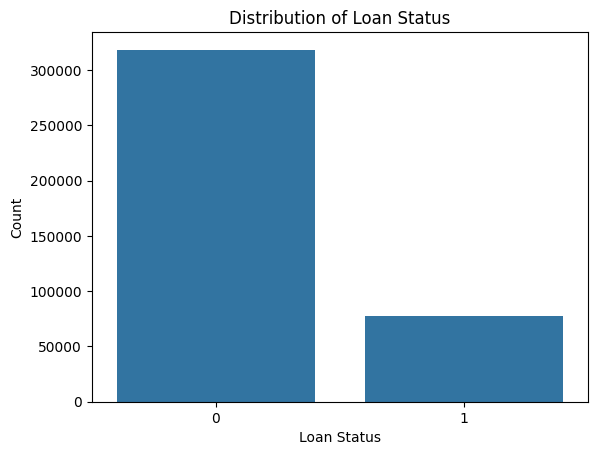

In [11]:
sns.countplot(x='loan_status', data=df)
plt.title('Distribution of Loan Status')
plt.xlabel('Loan Status')
plt.ylabel('Count')
plt.show()

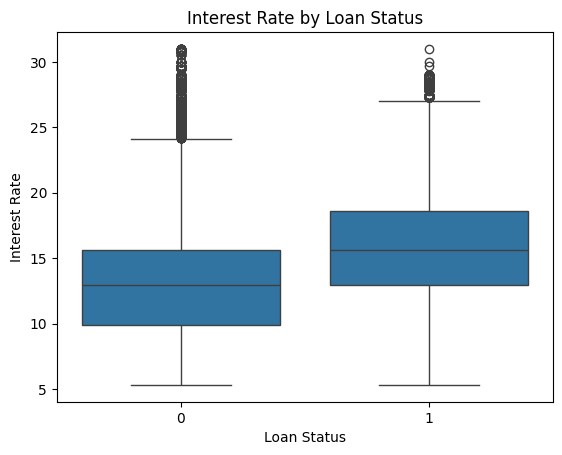

In [12]:
sns.boxplot(x='loan_status', y='int_rate', data=df)
plt.title('Interest Rate by Loan Status')
plt.xlabel('Loan Status')
plt.ylabel('Interest Rate')
plt.show()

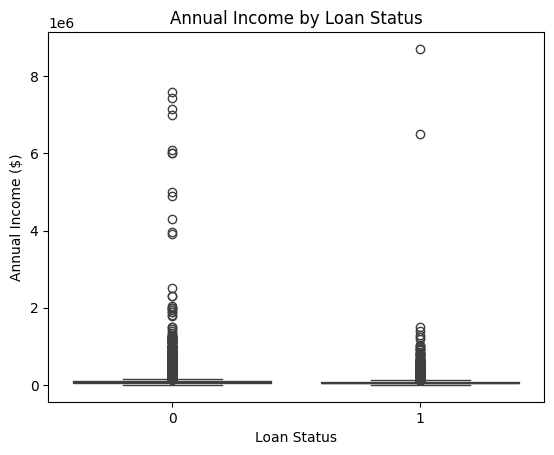

In [13]:
sns.boxplot(x='loan_status', y='annual_inc', data=df)
plt.title('Annual Income by Loan Status')
plt.xlabel('Loan Status')
plt.ylabel('Annual Income ($)')
plt.show()

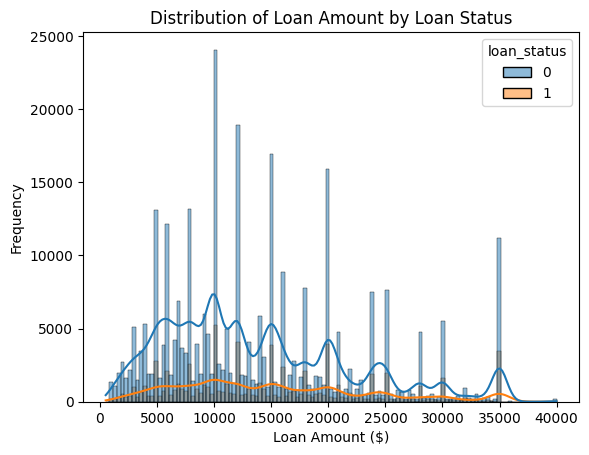

In [14]:
sns.histplot(data=df, x='loan_amnt', hue='loan_status', kde=True)
plt.title('Distribution of Loan Amount by Loan Status')
plt.xlabel('Loan Amount ($)')
plt.ylabel('Frequency')
plt.show()

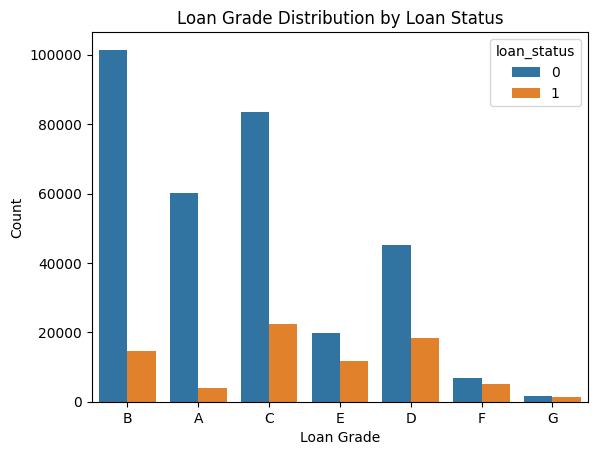

In [15]:
sns.countplot(x = 'grade', hue='loan_status', data=df )
plt.title('Loan Grade Distribution by Loan Status')
plt.xlabel('Loan Grade')
plt.ylabel('Count')
plt.show()

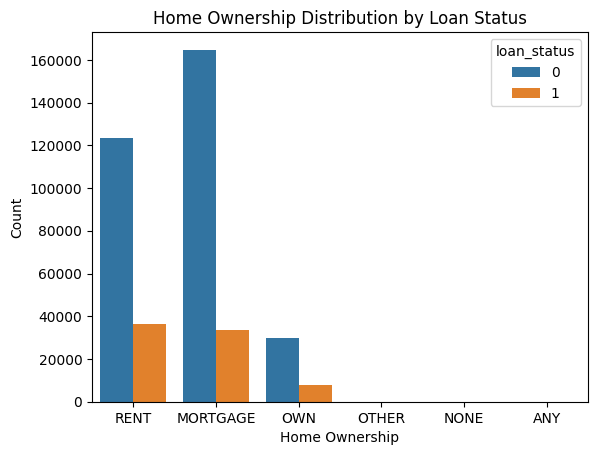

In [16]:
sns.countplot(x='home_ownership', hue='loan_status', data=df)
plt.title('Home Ownership Distribution by Loan Status')
plt.xlabel('Home Ownership')
plt.ylabel('Count')
plt.show()

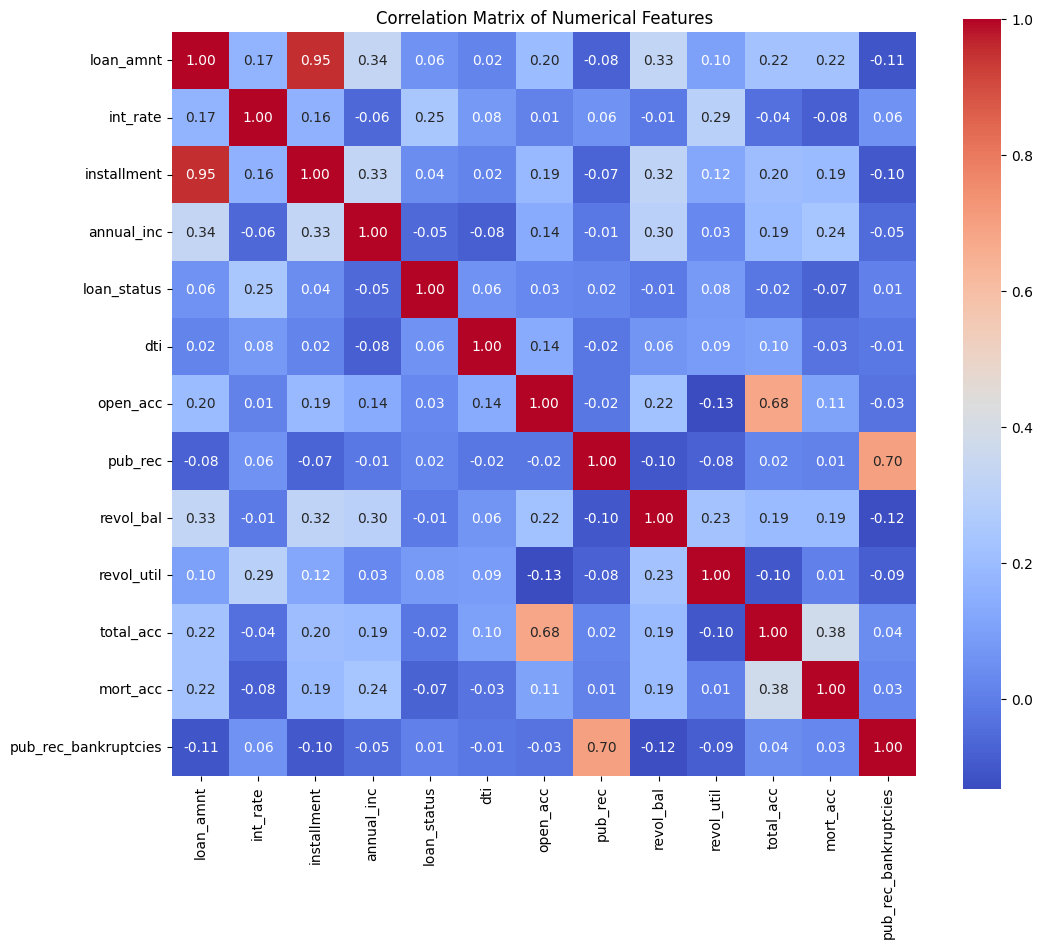

In [17]:
corr = df[numerical_cols].corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Correlation Matrix of Numerical Features')
plt.show()

In [18]:
corr_target = df[numerical_cols].corrwith(df['loan_status']).sort_values(ascending=False)
print("Correlation with Loan Status:")
print(corr_target)

Correlation with Loan Status:
loan_status             1.000000
int_rate                0.247758
revol_util              0.082373
dti                     0.062413
loan_amnt               0.059836
installment             0.041082
open_acc                0.028012
pub_rec                 0.019933
pub_rec_bankruptcies    0.009383
revol_bal              -0.010892
total_acc              -0.017893
annual_inc             -0.053432
mort_acc               -0.073111
dtype: float64


In [19]:
drop_cols  = ['Unnamed: 0']
df = df.drop(columns = [col for col in drop_cols if col in df.columns  ])


In [20]:
drop_cols = ['emp_title', 'title','address']
df = df.drop(columns = drop_cols)

In [21]:
missing = df.isnull().sum().sort_values(ascending=False)
missing.head(30)

mort_acc                37795
emp_length              18301
pub_rec_bankruptcies      535
revol_util                276
installment                 0
loan_amnt                   0
int_rate                    0
term                        0
home_ownership              0
sub_grade                   0
grade                       0
annual_inc                  0
purpose                     0
verification_status         0
issue_d                     0
loan_status                 0
open_acc                    0
earliest_cr_line            0
dti                         0
pub_rec                     0
total_acc                   0
revol_bal                   0
application_type            0
initial_list_status         0
dtype: int64

In [22]:
df['emp_length'] = df['emp_length'].fillna('Unknown')
df['mort_acc'] = df['mort_acc'].fillna(df['mort_acc'].median())
df['pub_rec_bankruptcies'] = df['pub_rec_bankruptcies'].fillna(0)
df['revol_util'] = df['revol_util'].fillna(df['revol_util'].median())


In [23]:
df.isnull().sum().sort_values(ascending=False).head(30)

loan_amnt               0
term                    0
int_rate                0
installment             0
grade                   0
sub_grade               0
emp_length              0
home_ownership          0
annual_inc              0
verification_status     0
issue_d                 0
loan_status             0
purpose                 0
dti                     0
earliest_cr_line        0
open_acc                0
pub_rec                 0
revol_bal               0
revol_util              0
total_acc               0
initial_list_status     0
application_type        0
mort_acc                0
pub_rec_bankruptcies    0
dtype: int64

In [24]:
df['issue_year'] = pd.to_datetime(df['issue_d']).dt.year
df['credit_history_year'] = pd.to_datetime(df['earliest_cr_line']).dt.year

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_10340\545648349.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['issue_year'] = pd.to_datetime(df['issue_d']).dt.year
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_10340\545648349.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['credit_history_year'] = pd.to_datetime(df['earliest_cr_line']).dt.year


In [25]:
df['credit_age'] = df['issue_year'] - df['credit_history_year']

In [26]:
df = df.drop(columns=['issue_d', 'earliest_cr_line'])

In [27]:
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
categorical_cols

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_10340\611271536.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object']).columns.tolist()


['term',
 'grade',
 'sub_grade',
 'emp_length',
 'home_ownership',
 'verification_status',
 'purpose',
 'initial_list_status',
 'application_type']

In [28]:
df = pd.get_dummies(df, columns=['home_ownership', 'verification_status', 'purpose', 'emp_length'], drop_first=True)
df['grade'] = df['grade'].astype('category').cat.codes 

In [29]:
df['loan_income_ratio'] = df['loan_amnt'] / df['annual_inc']

In [30]:
df['installment_income_ratio'] = df['installment'] / df['annual_inc']


In [31]:
df['depth_burden'] = df['dti'] * df['loan_amnt']

In [32]:
df = df.drop(columns = ['installment'])

In [33]:

df.head()

,loan_amnt,term,int_rate,grade,sub_grade,annual_inc,loan_status,dti,open_acc,pub_rec,...,emp_length_5 years,emp_length_6 years,emp_length_7 years,emp_length_8 years,emp_length_9 years,emp_length_< 1 year,emp_length_Unknown,loan_income_ratio,installment_income_ratio,depth_burden
0,10000.0,36 months,11.44,1,B4,117000.0,0,26.24,16.0,0.0,...,False,False,False,False,False,False,False,0.085470,0.002816,262400.00
1,8000.0,36 months,11.99,1,B5,65000.0,0,22.05,17.0,0.0,...,False,False,False,False,False,False,False,0.123077,0.004087,176400.00
2,15600.0,36 months,10.49,1,B3,43057.0,0,12.79,13.0,0.0,...,False,False,False,False,False,True,False,0.362310,0.011774,199524.00
3,7200.0,36 months,6.49,0,A2,54000.0,0,2.60,6.0,0.0,...,False,True,False,False,False,False,False,0.133333,0.004086,18720.00
4,24375.0,60 months,17.27,2,C5,55000.0,1,33.95,13.0,0.0,...,False,False,False,False,True,False,False,0.443182,0.011079,827531.25


In [34]:
df.shape

(396030, 54)

In [35]:
df.to_csv('../data/processed/loan_data_cleaned.csv', index=False)

In [39]:
X = df.drop('loan_status',axis= 1)
y = df['loan_status']  

In [40]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,stratify=y)


In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train = X_train.copy()
X_test = X_test.copy()

X_train['term'] = X_train['term'].astype(str).str.extract(r'(\d+)').astype(float)
X_test['term'] = X_test['term'].astype(str).str.extract(r'(\d+)').astype(float)

for col in ['sub_grade', 'initial_list_status', 'application_type']:
    cats = pd.Categorical(pd.concat([X_train[col], X_test[col]]))
    scaler = StandardScaler()

    X_train = X_train.copy()
    X_test = X_test.copy()

    X_train['term'] = X_train['term'].astype(str).str.extract(r'(\d+)').astype(float)
    X_test['term'] = X_test['term'].astype(str).str.extract(r'(\d+)').astype(float)

    for col in ['sub_grade', 'initial_list_status', 'application_type']:
        cats = pd.Categorical(pd.concat([X_train[col], X_test[col]]))
        X_train[col] = pd.Categorical(X_train[col], categories=cats.categories).codes
        X_test[col] = pd.Categorical(X_test[col], categories=cats.categories).codes

    X_train.replace([np.inf, -np.inf], np.nan, inplace=True)
    X_test.replace([np.inf, -np.inf], np.nan, inplace=True)

    impute_values = X_train.median()
    X_train = X_train.fillna(impute_values)
    X_test = X_test.fillna(impute_values)

    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    X_test[col] = pd.Categorical(X_test[col], categories=cats.categories).codes

X_train.replace([np.inf, -np.inf], np.nan, inplace=True)
X_test.replace([np.inf, -np.inf], np.nan, inplace=True)

impute_values = X_train.median()
X_train = X_train.fillna(impute_values)
X_test = X_test.fillna(impute_values)

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [46]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [47]:
y_pred = lr.predict(X_test_scaled)
y_prob = lr.predict_proba(X_test_scaled)[:, 1]

In [48]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
print("Classification Report:", classification_report(y_test, y_pred))
print("Confusion Matrix:", confusion_matrix(y_test, y_pred))
print("ROC AUC Score:", roc_auc_score(y_test, y_prob))

Classification Report:               precision    recall  f1-score   support

           0       0.82      0.98      0.89     63671
           1       0.53      0.10      0.16     15535

    accuracy                           0.81     79206
   macro avg       0.67      0.54      0.53     79206
weighted avg       0.76      0.81      0.75     79206

Confusion Matrix: [[62364  1307]
 [14046  1489]]
ROC AUC Score: 0.7133833420117599


In [49]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

In [50]:
print("Random Forest Classification Report:", classification_report(y_test, y_pred_rf))
print("Random Forest Confusion Matrix:", confusion_matrix(y_test, y_pred_rf))
print("Random Forest ROC AUC Score:", roc_auc_score(y_test, y_prob_rf))

Random Forest Classification Report:               precision    recall  f1-score   support

           0       0.82      0.98      0.89     63671
           1       0.55      0.09      0.15     15535

    accuracy                           0.81     79206
   macro avg       0.68      0.54      0.52     79206
weighted avg       0.76      0.81      0.75     79206

Random Forest Confusion Matrix: [[62517  1154]
 [14140  1395]]
Random Forest ROC AUC Score: 0.7132854159561405


In [54]:
from xgboost import XGBClassifier
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)

X_train_xgb = X_train.copy()
X_test_xgb = X_test.copy()

X_train_xgb.columns = X_train_xgb.columns.str.replace('[<>\[\]]', '', regex=True).str.replace(' ', '_')
X_test_xgb.columns = X_test_xgb.columns.str.replace('[<>\[\]]', '', regex=True).str.replace(' ', '_')

xgb.fit(X_train_xgb, y_train)

y_pred_xgb = xgb.predict(X_test_xgb)
y_prob_xgb = xgb.predict_proba(X_test_xgb)[:, 1]

y_prob_xgb = xgb.predict_proba(X_test_xgb)[:, 1]
y_prob_xgb = xgb.predict_proba(X_test_xgb)[:, 1]

<>:8: SyntaxWarning: invalid escape sequence '\['
<>:9: SyntaxWarning: invalid escape sequence '\['
<>:8: SyntaxWarning: invalid escape sequence '\['
<>:9: SyntaxWarning: invalid escape sequence '\['
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_10340\1813037714.py:8: SyntaxWarning: invalid escape sequence '\['
  X_train_xgb.columns = X_train_xgb.columns.str.replace('[<>\[\]]', '', regex=True).str.replace(' ', '_')
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_10340\1813037714.py:9: SyntaxWarning: invalid escape sequence '\['
  X_test_xgb.columns = X_test_xgb.columns.str.replace('[<>\[\]]', '', regex=True).str.replace(' ', '_')
d:\ML-Self\credit-risk-system\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [10:59:14] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [55]:
print("XGBoost Classification Report:", classification_report(y_test, y_pred_xgb))
print("XGBoost Confusion Matrix:", confusion_matrix(y_test, y_pred_xgb))
print("XGBoost ROC AUC Score:", roc_auc_score(y_test, y_prob_xgb))


XGBoost Classification Report:               precision    recall  f1-score   support

           0       0.82      0.98      0.89     63671
           1       0.55      0.12      0.19     15535

    accuracy                           0.81     79206
   macro avg       0.68      0.55      0.54     79206
weighted avg       0.77      0.81      0.75     79206

XGBoost Confusion Matrix: [[62172  1499]
 [13712  1823]]
XGBoost ROC AUC Score: 0.7271167642509232


In [56]:
import numpy as np
y_pred_custom = (y_prob_xgb > 0.3).astype(int)
print('classification report with custom threshold 0.3:')
print(classification_report(y_test, y_pred_custom))

classification report with custom threshold 0.3:
              precision    recall  f1-score   support

           0       0.86      0.85      0.85     63671
           1       0.41      0.43      0.42     15535

    accuracy                           0.77     79206
   macro avg       0.63      0.64      0.64     79206
weighted avg       0.77      0.77      0.77     79206



In [57]:
import shap
import pandas as pd
df = pd.read_csv('../data/processed/loan_data_cleaned.csv')
X = df.drop('loan_status', axis=1)
y = df['loan_status']

In [61]:
from xgboost import XGBClassifier
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
X_encoded = X.copy()
X_encoded['term'] = X_encoded['term'].astype(str).str.extract(r'(\d+)').astype(float)

for col in ['sub_grade', 'initial_list_status', 'application_type']:
    X_encoded[col] = pd.Categorical(X_encoded[col]).codes

X_encoded.columns = X_encoded.columns.str.replace('[<>\[\]]', '', regex=True).str.replace(' ', '_')
X_encoded.replace([np.inf, -np.inf], np.nan, inplace=True)
impute_values = X_encoded.median()
X_encoded = X_encoded.fillna(impute_values)
xgb.fit(X_encoded, y)

<>:9: SyntaxWarning: invalid escape sequence '\['
<>:9: SyntaxWarning: invalid escape sequence '\['
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_10340\1890473093.py:9: SyntaxWarning: invalid escape sequence '\['
  X_encoded.columns = X_encoded.columns.str.replace('[<>\[\]]', '', regex=True).str.replace(' ', '_')
d:\ML-Self\credit-risk-system\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [11:40:43] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [62]:
explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_encoded)

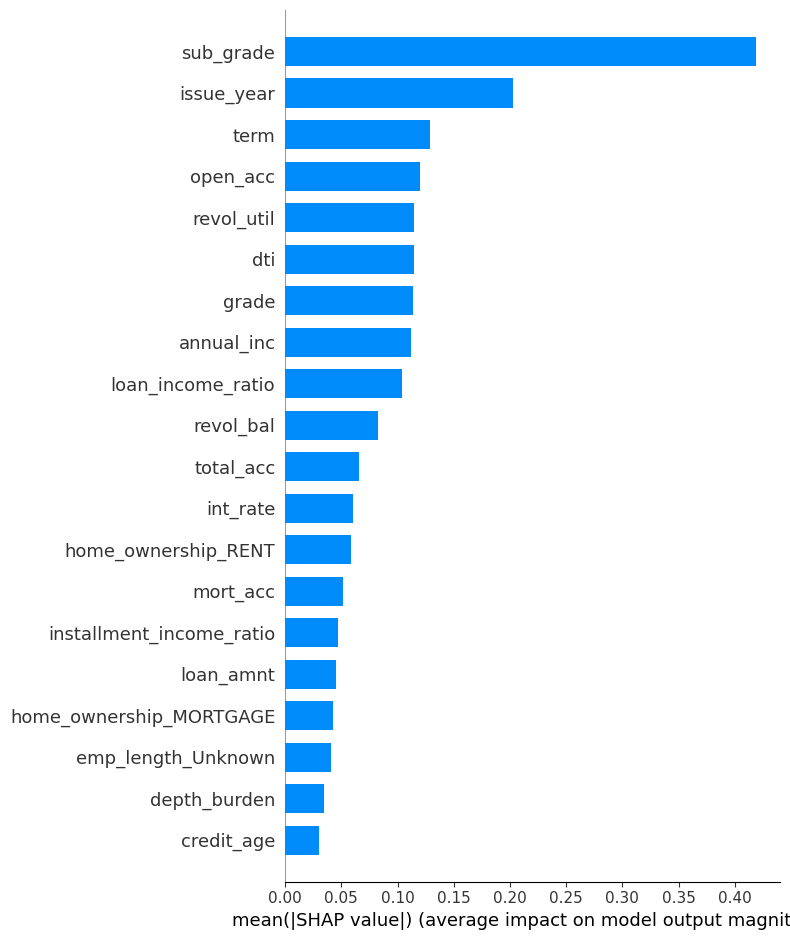

In [63]:
shap.summary_plot(shap_values, X_encoded, plot_type="bar")

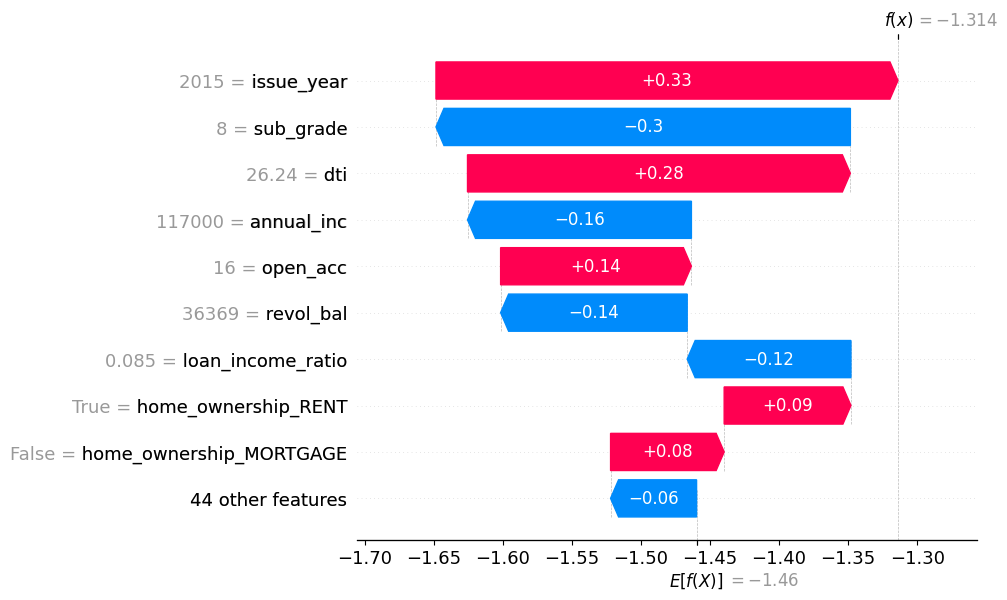

In [65]:
sample = X_encoded.iloc[0:1]
explanation = explainer(sample)
shap.plots.waterfall(explanation[0], max_display=10)

📊 Key Insights:
sub_grade is strongest predictor
interest rate & DTI strongly impact risk
income reduces risk
renters more likely to default
time-based feature (issue_year) needs validation


In [66]:
X_with_grade = X.copy()
X_without_grade = X_with_grade.drop(columns=['grade', 'sub_grade'])

In [67]:
X_train_A, X_test_A, y_train_A, y_test_A = train_test_split(X_with_grade, y, test_size=0.2, random_state=42,stratify=y)
X_train_B, X_test_B, y_train_B, y_test_B = train_test_split(X_without_grade, y, test_size=0.2, random_state=42,stratify=y)

In [71]:
from xgboost import XGBClassifier
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)

X_train_A = X_train_A.copy()
X_test_A = X_test_A.copy()

X_train_A['term'] = X_train_A['term'].astype(str).str.extract(r'(\d+)').astype(float)
X_test_A['term'] = X_test_A['term'].astype(str).str.extract(r'(\d+)').astype(float)

for col in ['sub_grade', 'initial_list_status', 'application_type']:
    cats = pd.Categorical(pd.concat([X_train_A[col], X_test_A[col]]))
    X_train_A[col] = pd.Categorical(X_train_A[col], categories=cats.categories).codes
    X_test_A[col] = pd.Categorical(X_test_A[col], categories=cats.categories).codes

X_train_A.columns = X_train_A.columns.str.replace('[<>\[\]]', '', regex=True).str.replace(' ', '_')
X_test_A.columns = X_test_A.columns.str.replace('[<>\[\]]', '', regex=True).str.replace(' ', '_')

X_train_A.replace([np.inf, -np.inf], np.nan, inplace=True)
X_test_A.replace([np.inf, -np.inf], np.nan, inplace=True)

impute_values = X_train_A.median()
X_train_A = X_train_A.fillna(impute_values)
X_test_A = X_test_A.fillna(impute_values)

# Clip values to prevent 'value too large' errors in XGBoost
X_train_A = X_train_A.clip(lower=-1e10, upper=1e10)
X_test_A = X_test_A.clip(lower=-1e10, upper=1e10)

X_train_A.columns = X_train_A.columns.str.replace('[<>\[\]]', '', regex=True).str.replace(' ', '_')
X_test_A.columns = X_test_A.columns.str.replace('[<>\[\]]', '', regex=True).str.replace(' ', '_')

xgb.fit(X_train_A, y_train_A)

y_pred_A = xgb.predict(X_test_A)
y_prob_A = xgb.predict_proba(X_test_A)[:, 1]

y_prob_A = xgb.predict_proba(X_test_A)[:, 1]

y_prob_A = xgb.predict_proba(X_test_A)[:, 1]

y_prob_A = xgb.predict_proba(X_test_A)[:, 1]

<>:16: SyntaxWarning: invalid escape sequence '\['
<>:17: SyntaxWarning: invalid escape sequence '\['
<>:30: SyntaxWarning: invalid escape sequence '\['
<>:31: SyntaxWarning: invalid escape sequence '\['
<>:16: SyntaxWarning: invalid escape sequence '\['
<>:17: SyntaxWarning: invalid escape sequence '\['
<>:30: SyntaxWarning: invalid escape sequence '\['
<>:31: SyntaxWarning: invalid escape sequence '\['
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_10340\2419554111.py:16: SyntaxWarning: invalid escape sequence '\['
  X_train_A.columns = X_train_A.columns.str.replace('[<>\[\]]', '', regex=True).str.replace(' ', '_')
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_10340\2419554111.py:17: SyntaxWarning: invalid escape sequence '\['
  X_test_A.columns = X_test_A.columns.str.replace('[<>\[\]]', '', regex=True).str.replace(' ', '_')
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_10340\2419554111.py:30: SyntaxWarning: invalid escape sequence '\['
  X_train_A.columns = X_train_A.columns.str.replace

In [74]:
from xgboost import XGBClassifier
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)

X_train_B = X_train_B.copy()
X_test_B = X_test_B.copy()

X_train_B['term'] = X_train_B['term'].astype(str).str.extract(r'(\d+)').astype(float)
X_test_B['term'] = X_test_B['term'].astype(str).str.extract(r'(\d+)').astype(float)

for col in ['sub_grade', 'initial_list_status', 'application_type']:
    if col in X_train_B.columns:
        cats = pd.Categorical(pd.concat([X_train_B[col], X_test_B[col]]))
        X_train_B[col] = pd.Categorical(X_train_B[col], categories=cats.categories).codes
        X_test_B[col] = pd.Categorical(X_test_B[col], categories=cats.categories).codes

X_train_B.columns = X_train_B.columns.str.replace('[<>\[\]]', '', regex=True).str.replace(' ', '_')
X_test_B.columns = X_test_B.columns.str.replace('[<>\[\]]', '', regex=True).str.replace(' ', '_')

X_train_B.replace([np.inf, -np.inf], np.nan, inplace=True)
X_test_B.replace([np.inf, -np.inf], np.nan, inplace=True)

impute_values = X_train_B.median()
X_train_B = X_train_B.fillna(impute_values)
X_test_B = X_test_B.fillna(impute_values)

# Clip values to prevent 'value too large' errors in XGBoost
X_train_B = X_train_B.clip(lower=-1e10, upper=1e10)
X_test_B = X_test_B.clip(lower=-1e10, upper=1e10)

X_train_B.columns = X_train_B.columns.str.replace('[<>\[\]]', '', regex=True).str.replace(' ', '_')
X_test_B.columns = X_test_B.columns.str.replace('[<>\[\]]', '', regex=True).str.replace(' ', '_')

xgb.fit(X_train_B, y_train_B)

y_pred_B = xgb.predict(X_test_B)
y_prob_B = xgb.predict_proba(X_test_B)[:, 1]

y_prob_B = xgb.predict_proba(X_test_B)[:, 1]

y_prob_B = xgb.predict_proba(X_test_B)[:, 1]

y_prob_B = xgb.predict_proba(X_test_B)[:, 1]

<>:17: SyntaxWarning: invalid escape sequence '\['
<>:18: SyntaxWarning: invalid escape sequence '\['
<>:31: SyntaxWarning: invalid escape sequence '\['
<>:32: SyntaxWarning: invalid escape sequence '\['
<>:17: SyntaxWarning: invalid escape sequence '\['
<>:18: SyntaxWarning: invalid escape sequence '\['
<>:31: SyntaxWarning: invalid escape sequence '\['
<>:32: SyntaxWarning: invalid escape sequence '\['
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_10340\3868525541.py:17: SyntaxWarning: invalid escape sequence '\['
  X_train_B.columns = X_train_B.columns.str.replace('[<>\[\]]', '', regex=True).str.replace(' ', '_')
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_10340\3868525541.py:18: SyntaxWarning: invalid escape sequence '\['
  X_test_B.columns = X_test_B.columns.str.replace('[<>\[\]]', '', regex=True).str.replace(' ', '_')
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_10340\3868525541.py:31: SyntaxWarning: invalid escape sequence '\['
  X_train_B.columns = X_train_B.columns.str.replace

In [75]:
threshold = 0.3
y_pred_A_custom = (y_prob_A > threshold).astype(int)
y_pred_B_custom = (y_prob_B > threshold).astype(int)


In [76]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
print('\n=====With Grade=======')
print("Classification Report:")
print(classification_report(y_test_A, y_pred_A_custom))
print("Confusion Matrix:")
print(confusion_matrix(y_test_A, y_pred_A_custom))
print("ROC AUC Score:")
print(roc_auc_score(y_test_A, y_prob_A))



print('\n=====Without Grade=======')
print("Classification Report:")
print(classification_report(y_test_B, y_pred_B_custom))
print("Confusion Matrix:")
print(confusion_matrix(y_test_B, y_pred_B_custom))
print("ROC AUC Score:")
print(roc_auc_score(y_test_B, y_prob_B))




=====With Grade=======
Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.85      0.85     63671
           1       0.41      0.43      0.42     15535

    accuracy                           0.77     79206
   macro avg       0.63      0.64      0.64     79206
weighted avg       0.77      0.77      0.77     79206

Confusion Matrix:
[[53914  9757]
 [ 8829  6706]]
ROC AUC Score:
0.7271167642509232

=====Without Grade=======
Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.85      0.85     63671
           1       0.41      0.43      0.42     15535

    accuracy                           0.77     79206
   macro avg       0.63      0.64      0.63     79206
weighted avg       0.77      0.77      0.77     79206

Confusion Matrix:
[[54013  9658]
 [ 8917  6618]]
ROC AUC Score:
0.7261678217831216
